# TensorFlow Hourly Rainfall Forecasting In Local Time

This notebook trains a timestamp-driven MLP rainfall model for ESP32 deployment from `historical_weather_data_hourly.csv` in the `weather_irrigation_hourly` folder. Inference uses only the forecast timestamp, while training derives date and time features from local-time history before exporting TensorFlow Lite and C array artifacts.

## 1. Imports

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, average_precision_score, brier_score_loss, f1_score, mean_absolute_error, precision_score, r2_score, recall_score, roc_auc_score, root_mean_squared_error
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Input

tf.keras.utils.set_random_seed(42)
np.random.seed(42)

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'historical_weather_data_hourly.csv'
KERAS_MODEL_PATH = BASE_DIR / 'hourly_rainfall_forecaster.keras'
TFLITE_MODEL_PATH = BASE_DIR / 'hourly_rainfall_forecaster.tflite'
CC_MODEL_PATH = BASE_DIR / 'hourly_rainfall_forecaster.cc'
H_MODEL_PATH = BASE_DIR / 'hourly_rainfall_forecaster.h'
METRICS_PATH = BASE_DIR / 'hourly_rainfall_metrics.json'
FEATURE_COLUMNS_PATH = BASE_DIR / 'hourly_feature_columns.json'
X_MEAN_PATH = BASE_DIR / 'hourly_X_mean.npy'
X_STD_PATH = BASE_DIR / 'hourly_X_std.npy'
Y_AMOUNT_MEAN_PATH = BASE_DIR / 'hourly_y_amount_mean.npy'
Y_AMOUNT_STD_PATH = BASE_DIR / 'hourly_y_amount_std.npy'
RAIN_THRESHOLD_MM = 0.1
C_ARRAY_NAME = 'hourly_rainfall_forecaster_tflite'


I0000 00:00:1778185719.165499  310372 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2. Load Local-Time Hourly History

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        'historical_weather_data_hourly.csv was not found. Run fetch_hourly_weather_data.py first.'
    )

df = pd.read_csv(DATA_PATH, parse_dates=['time'])
df = df.sort_values('time').reset_index(drop=True)
df['rain_mm'] = df['rain_mm'].clip(lower=0)
df['rain_occurrence'] = (df['rain_mm'] >= RAIN_THRESHOLD_MM).astype(np.float32)
print(df[['time', 'time_utc', 'rain_mm', 'precipitation_probability', 'cloud_cover_total_percent']].head())
print(f'Loaded {len(df):,} hourly rows from {df.time.min()} to {df.time.max()}')


                 time              time_utc  rain_mm  \
0 2020-01-01 00:00:00  2020-01-01T00:00:00Z      0.0   
1 2020-01-01 01:00:00  2020-01-01T01:00:00Z      0.0   
2 2020-01-01 02:00:00  2020-01-01T02:00:00Z      0.0   
3 2020-01-01 03:00:00  2020-01-01T03:00:00Z      0.0   
4 2020-01-01 04:00:00  2020-01-01T04:00:00Z      0.0   

   precipitation_probability  cloud_cover_total_percent  
0                        NaN                         36  
1                        NaN                         27  
2                        NaN                         27  
3                        NaN                         22  
4                        NaN                         17  
Loaded 52,608 hourly rows from 2020-01-01 00:00:00 to 2025-12-31 23:00:00


## 3. Calendar Feature Engineering

These features are designed to capture the structure that repeats on the calendar without leaking future rainfall values into the model. Rainfall tends to vary by season, time of day, and position in the year, so the notebook encodes those cycles explicitly. The `month`, `hour`, `day_of_year`, `day_of_week`, and `day_of_month` terms are represented with sine and cosine pairs so the model sees that the end of a cycle wraps smoothly back to the beginning. Second harmonics are added for hour and day-of-year because rainfall patterns are often not simple single-wave curves.

The climatology features summarize the historical average rainfall amount and rainfall probability for the same month-hour and day-of-year-hour combinations. Those columns give the network a compact prior for the expected local weather regime at a timestamp before the dense layers learn non-linear interactions. `year_index` is included to let the model absorb slow multi-year drift, while `is_weekend` is a lightweight calendar flag that is cheap to test and can be removed later if it proves uninformative.

In [3]:
def cyclical_columns(values: pd.Series, period: float, prefix: str, harmonics: int = 1) -> dict[str, np.ndarray]:
    angles = 2 * np.pi * values.to_numpy(dtype=float) / period
    features = {}
    for harmonic in range(1, harmonics + 1):
        features[f'{prefix}_sin_{harmonic}'] = np.sin(harmonic * angles)
        features[f'{prefix}_cos_{harmonic}'] = np.cos(harmonic * angles)
    return features

def build_climatology(frame: pd.DataFrame) -> dict:
    train = frame.copy()
    month_hour = train.groupby(['month_eat', 'hour_eat'])[['rain_mm', 'rain_occurrence']].mean().reset_index()
    doy_hour = train.groupby(['day_of_year_eat', 'hour_eat'])[['rain_mm', 'rain_occurrence']].mean().reset_index()
    return {
        'month_hour_amount': {(int(r.month_eat), int(r.hour_eat)): float(r.rain_mm) for r in month_hour.itertuples()},
        'month_hour_probability': {(int(r.month_eat), int(r.hour_eat)): float(r.rain_occurrence) for r in month_hour.itertuples()},
        'doy_hour_amount': {(int(r.day_of_year_eat), int(r.hour_eat)): float(r.rain_mm) for r in doy_hour.itertuples()},
        'doy_hour_probability': {(int(r.day_of_year_eat), int(r.hour_eat)): float(r.rain_occurrence) for r in doy_hour.itertuples()},
        'global_amount': float(train['rain_mm'].mean()),
        'global_probability': float(train['rain_occurrence'].mean()),
    }

def build_features(timestamps: pd.Series, climatology: dict) -> pd.DataFrame:
    ts = pd.to_datetime(timestamps)
    month = ts.dt.month
    hour = ts.dt.hour
    minute = ts.dt.minute
    day_of_year = ts.dt.dayofyear
    day_of_week = ts.dt.dayofweek
    day_of_month = ts.dt.day
    year_index = ts.dt.year - ts.dt.year.min()
    month_hour_keys = list(zip(month, hour))
    doy_hour_keys = list(zip(day_of_year, hour))

    features = {
        'year_index': year_index.to_numpy(dtype=float),
        'is_weekend': (day_of_week >= 5).astype(float).to_numpy(),
        'month_hour_amount_climatology': np.array([climatology['month_hour_amount'].get(k, climatology['global_amount']) for k in month_hour_keys]),
        'month_hour_probability_climatology': np.array([climatology['month_hour_probability'].get(k, climatology['global_probability']) for k in month_hour_keys]),
        'doy_hour_amount_climatology': np.array([climatology['doy_hour_amount'].get(k, climatology['global_amount']) for k in doy_hour_keys]),
        'doy_hour_probability_climatology': np.array([climatology['doy_hour_probability'].get(k, climatology['global_probability']) for k in doy_hour_keys]),
    }
    features.update(cyclical_columns(month, 12.0, 'month'))
    features.update(cyclical_columns(hour + minute / 60.0, 24.0, 'hour', harmonics=2))
    features.update(cyclical_columns(day_of_year, 365.25, 'doy', harmonics=2))
    features.update(cyclical_columns(day_of_week, 7.0, 'dow'))
    features.update(cyclical_columns(day_of_month, 31.0, 'dom'))
    return pd.DataFrame(features, index=ts.index).astype(np.float32)


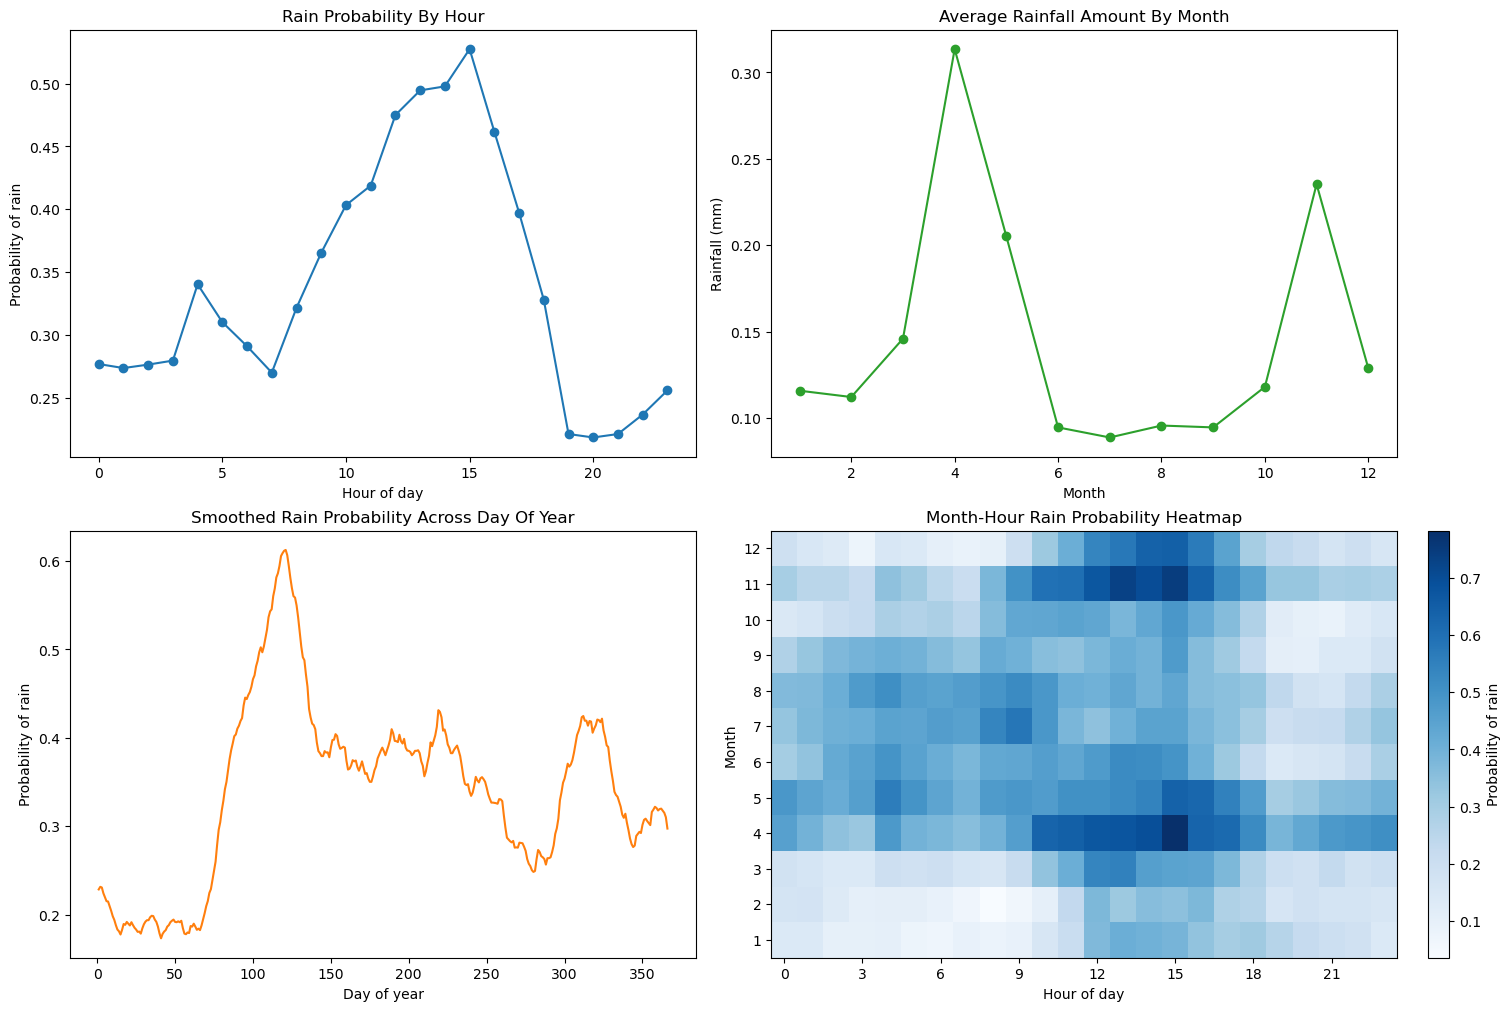

Feature rationale summary:
- Hour features capture the strong within-day change visible in rain probability.
- Month and day-of-year features capture the seasonal shift in rainfall intensity and frequency.
- Climatology features summarize the month-hour and day-of-year-hour structure shown above.
- Cyclical encoding avoids artificial jumps such as 23:00 to 00:00 or December to January.


In [4]:
calendar_diagnostics = df.copy()
calendar_diagnostics['rolling_rain_probability'] = (
    calendar_diagnostics.groupby('day_of_year_eat')['rain_occurrence']
    .mean()
    .rolling(window=21, center=True, min_periods=1)
    .mean()
)
month_hour_probability = df.pivot_table(
    index='month_eat',
    columns='hour_eat',
    values='rain_occurrence',
    aggfunc='mean'
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
df.groupby('hour_eat')['rain_occurrence'].mean().plot(ax=axes[0, 0], marker='o', color='tab:blue')
axes[0, 0].set_title('Rain Probability By Hour')
axes[0, 0].set_xlabel('Hour of day')
axes[0, 0].set_ylabel('Probability of rain')

df.groupby('month_eat')['rain_mm'].mean().plot(ax=axes[0, 1], marker='o', color='tab:green')
axes[0, 1].set_title('Average Rainfall Amount By Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Rainfall (mm)')

calendar_diagnostics['rolling_rain_probability'].plot(ax=axes[1, 0], color='tab:orange')
axes[1, 0].set_title('Smoothed Rain Probability Across Day Of Year')
axes[1, 0].set_xlabel('Day of year')
axes[1, 0].set_ylabel('Probability of rain')

im = axes[1, 1].imshow(month_hour_probability.to_numpy(), aspect='auto', cmap='Blues', origin='lower')
axes[1, 1].set_title('Month-Hour Rain Probability Heatmap')
axes[1, 1].set_xlabel('Hour of day')
axes[1, 1].set_ylabel('Month')
axes[1, 1].set_xticks(range(0, 24, 3))
axes[1, 1].set_yticks(range(12))
axes[1, 1].set_yticklabels(month_hour_probability.index.astype(int))
fig.colorbar(im, ax=axes[1, 1], label='Probability of rain')
plt.show()

print('Feature rationale summary:')
print('- Hour features capture the strong within-day change visible in rain probability.')
print('- Month and day-of-year features capture the seasonal shift in rainfall intensity and frequency.')
print('- Climatology features summarize the month-hour and day-of-year-hour structure shown above.')
print('- Cyclical encoding avoids artificial jumps such as 23:00 to 00:00 or December to January.')


## 4. Time-Based Split And Scaling

The train-test split is chronological instead of random because forecasting must use the past to predict the future. A random split would leak future seasonal states into training and make evaluation look better than real deployment. Using the first 80% of the timeline for training and the latest 20% for testing gives a more realistic estimate of how the model behaves on unseen future months.

Scaling is fit on the training window only and then reused for the test window. That keeps the preprocessing aligned with deployment, where future data statistics are not known in advance. The target rainfall amount is log-scaled before standardization because hourly rain is highly right-skewed: many dry hours and a small number of heavy-rain events. The log transform compresses those spikes so the regression loss is less dominated by a few extreme hours.

In [5]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()
climatology = build_climatology(train_df)

X_train_df = build_features(train_df['time'], climatology)
X_test_df = build_features(test_df['time'], climatology)
feature_columns = list(X_train_df.columns)

X_train = X_train_df.to_numpy(dtype=np.float32)
X_test = X_test_df.to_numpy(dtype=np.float32)
y_train_amount = train_df['rain_mm'].to_numpy(dtype=np.float32)
y_test_amount = test_df['rain_mm'].to_numpy(dtype=np.float32)
y_train_rain = train_df['rain_occurrence'].to_numpy(dtype=np.float32)
y_test_rain = test_df['rain_occurrence'].to_numpy(dtype=np.float32)

month_hour_keys_test = list(zip(test_df['month_eat'], test_df['hour_eat']))
baseline_amount = np.array([climatology['month_hour_amount'].get(k, climatology['global_amount']) for k in month_hour_keys_test], dtype=np.float32)
baseline_probability = np.array([climatology['month_hour_probability'].get(k, climatology['global_probability']) for k in month_hour_keys_test], dtype=np.float32)
persistence_amount_last_hour = df['rain_mm'].shift(1).iloc[split_idx:].to_numpy(dtype=np.float32)
persistence_probability_last_hour = df['rain_occurrence'].shift(1).iloc[split_idx:].to_numpy(dtype=np.float32)

X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_std[X_std == 0] = 1e-6
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

y_train_amount_log = np.log1p(y_train_amount)
y_amount_mean = y_train_amount_log.mean()
y_amount_std = y_train_amount_log.std()
if y_amount_std == 0:
    y_amount_std = 1e-6
y_train_amount_scaled = ((y_train_amount_log - y_amount_mean) / y_amount_std).astype(np.float32)

np.save(X_MEAN_PATH, X_mean)
np.save(X_STD_PATH, X_std)
np.save(Y_AMOUNT_MEAN_PATH, np.array([y_amount_mean], dtype=np.float32))
np.save(Y_AMOUNT_STD_PATH, np.array([y_amount_std], dtype=np.float32))
FEATURE_COLUMNS_PATH.write_text(json.dumps(feature_columns, indent=2))
print(f'Train rows: {len(train_df):,}, test rows: {len(test_df):,}')
print(f'Feature count: {X_train_scaled.shape[1]}')


Train rows: 42,086, test rows: 10,522
Feature count: 20


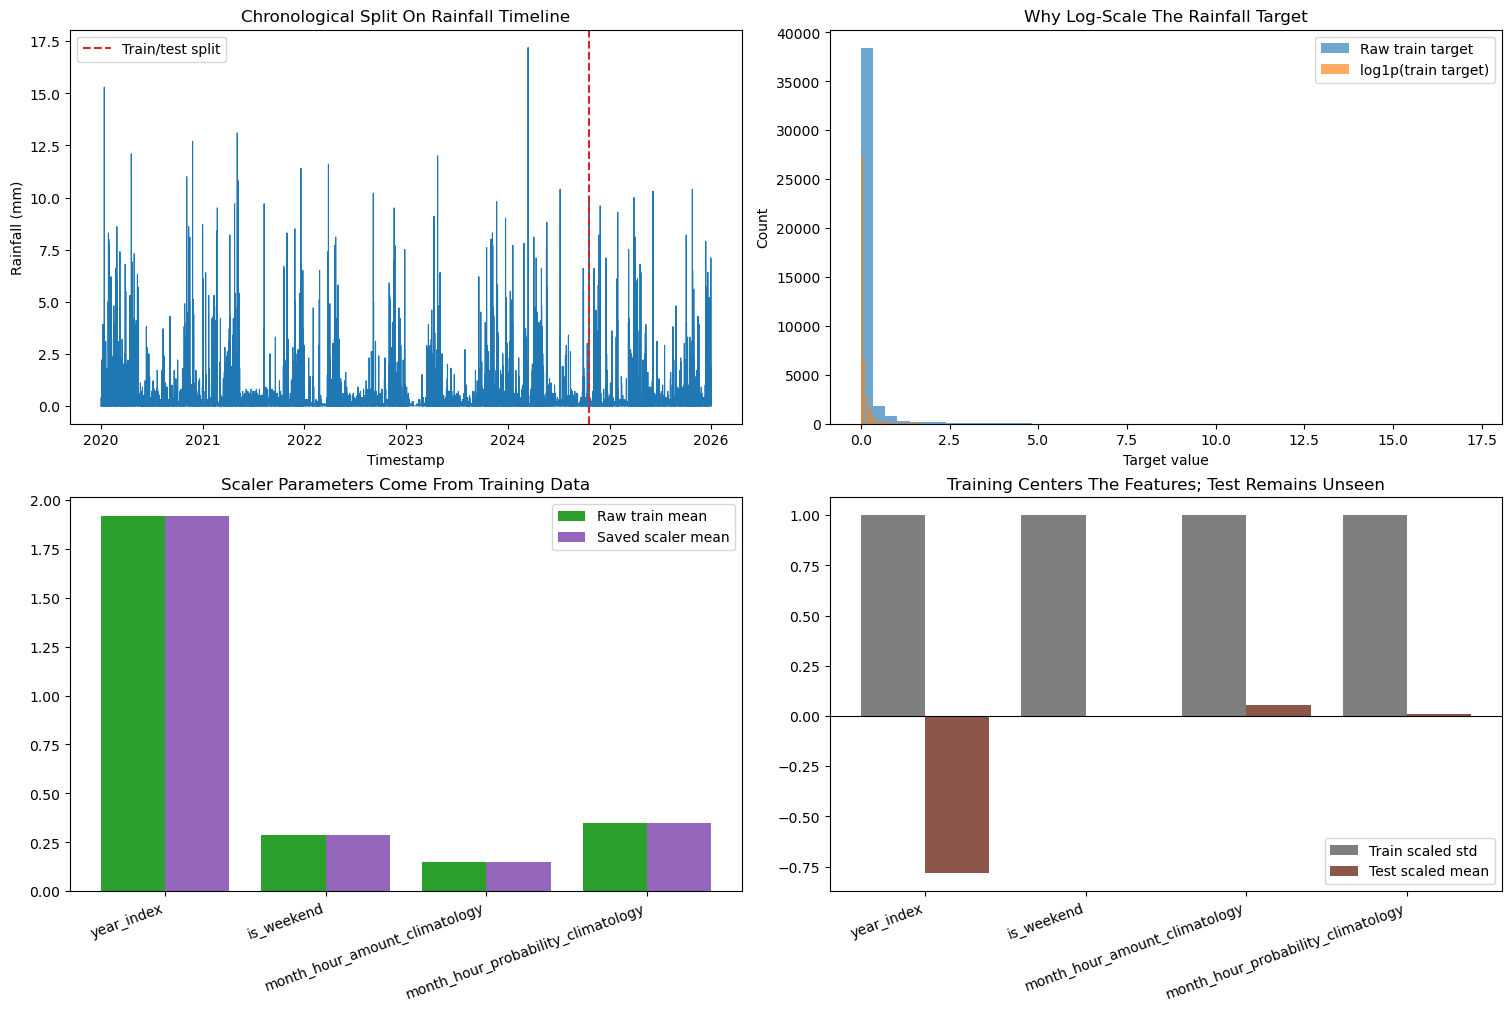

Split and scaling rationale summary:
- The split is chronological so evaluation reflects true forward-looking forecasting.
- Scaling parameters are estimated on the training window only to avoid look-ahead leakage.
- The test set is intentionally not re-centered to zero; any shift there reflects real distribution change.
- log1p rainfall scaling reduces the dominance of rare heavy-rain hours in the regression loss.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

axes[0, 0].plot(df['time'], df['rain_mm'], color='tab:blue', linewidth=0.8)
axes[0, 0].axvline(df.loc[split_idx, 'time'], color='tab:red', linestyle='--', label='Train/test split')
axes[0, 0].set_title('Chronological Split On Rainfall Timeline')
axes[0, 0].set_xlabel('Timestamp')
axes[0, 0].set_ylabel('Rainfall (mm)')
axes[0, 0].legend()

axes[0, 1].hist(y_train_amount, bins=50, alpha=0.65, label='Raw train target', color='tab:blue')
axes[0, 1].hist(np.log1p(y_train_amount), bins=50, alpha=0.65, label='log1p(train target)', color='tab:orange')
axes[0, 1].set_title('Why Log-Scale The Rainfall Target')
axes[0, 1].set_xlabel('Target value')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

sample_feature_names = feature_columns[:4]
sample_indices = [feature_columns.index(name) for name in sample_feature_names]
x = np.arange(len(sample_feature_names))
train_feature_mean = X_train[:, sample_indices].mean(axis=0)
train_feature_std = X_train_scaled[:, sample_indices].std(axis=0)
test_feature_mean_scaled = X_test_scaled[:, sample_indices].mean(axis=0)
axes[1, 0].bar(x - 0.2, train_feature_mean, width=0.4, label='Raw train mean', color='tab:green')
axes[1, 0].bar(x + 0.2, X_mean[sample_indices], width=0.4, label='Saved scaler mean', color='tab:purple')
axes[1, 0].set_title('Scaler Parameters Come From Training Data')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(sample_feature_names, rotation=20, ha='right')
axes[1, 0].legend()

axes[1, 1].bar(x - 0.2, train_feature_std, width=0.4, label='Train scaled std', color='tab:gray')
axes[1, 1].bar(x + 0.2, test_feature_mean_scaled, width=0.4, label='Test scaled mean', color='tab:brown')
axes[1, 1].axhline(0.0, color='black', linewidth=0.8)
axes[1, 1].set_title('Training Centers The Features; Test Remains Unseen')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(sample_feature_names, rotation=20, ha='right')
axes[1, 1].legend()
plt.show()

print('Split and scaling rationale summary:')
print('- The split is chronological so evaluation reflects true forward-looking forecasting.')
print('- Scaling parameters are estimated on the training window only to avoid look-ahead leakage.')
print('- The test set is intentionally not re-centered to zero; any shift there reflects real distribution change.')
print('- log1p rainfall scaling reduces the dominance of rare heavy-rain hours in the regression loss.')


## 5. TensorFlow MLP Model

In [7]:
inputs = Input(shape=(X_train_scaled.shape[1],), name='calendar_features')
x = Dense(64, activation='relu')(inputs)
x = Dropout(0.15)(x)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)
amount_output = Dense(1, name='amount_output')(x)
probability_output = Dense(1, activation='sigmoid', name='probability_output')(x)

model = Model(inputs=inputs, outputs=[amount_output, probability_output])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        'amount_output': 'mse',
        'probability_output': 'binary_crossentropy',
    },
    loss_weights={
        'amount_output': 1.0,
        'probability_output': 0.7,
    },
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ calendar_features   │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,344 │ calendar_feature… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ amount_output       │ (None, 1)         │         17 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ probability_output  │ (None, 1)         │         17 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,986 (15.57 KB)

 Trainable params: 3,986 (15.57 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train

In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-5),
]

history = model.fit(
    X_train_scaled,
    {
        'amount_output': y_train_amount_scaled,
        'probability_output': y_train_rain,
    },
    validation_split=0.2,
    epochs=250,
    batch_size=32,
    verbose=0,
    callbacks=callbacks,
)

print(f"Training stopped after {len(history.history['loss'])} epochs.")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")


Training stopped after 21 epochs.
Best val_loss: 1.2175


## 7. Evaluate

In [9]:
amount_pred_scaled, probability_pred = model.predict(X_test_scaled, verbose=0)
amount_pred_scaled = amount_pred_scaled.reshape(-1)
probability_pred = probability_pred.reshape(-1)
amount_pred = np.expm1((amount_pred_scaled * y_amount_std) + y_amount_mean).clip(min=0)
rainy_mask = y_test_amount >= RAIN_THRESHOLD_MM

def safe_float(value):
    return None if pd.isna(value) else float(value)

def amount_metrics(y_true, y_pred):
    rainy_true = y_true[rainy_mask]
    rainy_pred = y_pred[rainy_mask]
    return {
        'mae_mm': float(mean_absolute_error(y_true, y_pred)),
        'rmse_mm': float(root_mean_squared_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'rainy_hours_count': int(rainy_mask.sum()),
        'rainy_mae_mm': safe_float(mean_absolute_error(rainy_true, rainy_pred)) if len(rainy_true) else None,
        'rainy_rmse_mm': safe_float(root_mean_squared_error(rainy_true, rainy_pred)) if len(rainy_true) else None,
    }

def probability_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(np.float32)
    positives = int(y_true.sum())
    negatives = int(len(y_true) - positives)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    roc_auc = roc_auc_score(y_true, y_prob) if positives and negatives else np.nan
    pr_auc = average_precision_score(y_true, y_prob) if positives else np.nan
    return {
        'brier_score': float(brier_score_loss(y_true, y_prob)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'roc_auc': safe_float(roc_auc),
        'pr_auc': safe_float(pr_auc),
        'positive_hours': positives,
        'negative_hours': negatives,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
    }

metrics = {
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'feature_columns': feature_columns,
    'amount_models': {
        'mlp': amount_metrics(y_test_amount, amount_pred),
        'climatology_month_hour': amount_metrics(y_test_amount, baseline_amount),
        'persistence_last_hour': amount_metrics(y_test_amount, persistence_amount_last_hour),
    },
    'probability_models': {
        'mlp': probability_metrics(y_test_rain, probability_pred),
        'climatology_month_hour': probability_metrics(y_test_rain, baseline_probability),
        'persistence_last_hour': probability_metrics(y_test_rain, persistence_probability_last_hour),
    },
}
metrics['selected_amount_model'] = min(
    metrics['amount_models'],
    key=lambda name: (
        metrics['amount_models'][name]['rmse_mm'],
        metrics['amount_models'][name]['mae_mm'],
    ),
)
metrics['selected_probability_model'] = min(
    metrics['probability_models'],
    key=lambda name: (
        metrics['probability_models'][name]['brier_score'],
        -metrics['probability_models'][name]['f1'],
    ),
)
print(json.dumps(metrics, indent=2))


{
  "train_rows": 42086,
  "test_rows": 10522,
  "feature_columns": [
    "year_index",
    "is_weekend",
    "month_hour_amount_climatology",
    "month_hour_probability_climatology",
    "doy_hour_amount_climatology",
    "doy_hour_probability_climatology",
    "month_sin_1",
    "month_cos_1",
    "hour_sin_1",
    "hour_cos_1",
    "hour_sin_2",
    "hour_cos_2",
    "doy_sin_1",
    "doy_cos_1",
    "doy_sin_2",
    "doy_cos_2",
    "dow_sin_1",
    "dow_cos_1",
    "dom_sin_1",
    "dom_cos_1"
  ],
  "amount_models": {
    "mlp": {
      "mae_mm": 0.20112009346485138,
      "rmse_mm": 0.572400689125061,
      "r2": -0.08262205123901367,
      "rainy_hours_count": 3184,
      "rainy_mae_mm": 0.39333197474479675,
      "rainy_rmse_mm": 0.9869745373725891
    },
    "climatology_month_hour": {
      "mae_mm": 0.20468920469284058,
      "rmse_mm": 0.5451643466949463,
      "r2": 0.01795482635498047,
      "rainy_hours_count": 3184,
      "rainy_mae_mm": 0.37300872802734375,
      "ra

## 8. Export Keras, TFLite, And ESP32 Artifacts

In [10]:
def convert_tflite_to_c_array(tflite_path: Path, c_file_path: Path, h_file_path: Path, array_name: str):
    tflite_content = tflite_path.read_bytes()
    hex_array = [f'0x{byte:02x}' for byte in tflite_content]

    with c_file_path.open('w') as c_file:
        c_file.write(f'#include "{h_file_path.name}"\n\n')
        c_file.write(f'const unsigned char {array_name}[] = {{\n')
        for idx in range(0, len(hex_array), 12):
            c_file.write('  ' + ', '.join(hex_array[idx:idx + 12]) + ',\n')
        c_file.write('};\n\n')
        c_file.write(f'const int {array_name}_len = {len(tflite_content)};\n')

    with h_file_path.open('w') as h_file:
        guard = h_file_path.stem.upper() + '_H'
        h_file.write(f'#ifndef {guard}\n')
        h_file.write(f'#define {guard}\n\n')
        h_file.write(f'extern const unsigned char {array_name}[];\n')
        h_file.write(f'extern const int {array_name}_len;\n\n')
        h_file.write(f'#endif  // {guard}\n')

model.save(KERAS_MODEL_PATH)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
TFLITE_MODEL_PATH.write_bytes(tflite_model)
convert_tflite_to_c_array(TFLITE_MODEL_PATH, CC_MODEL_PATH, H_MODEL_PATH, C_ARRAY_NAME)
METRICS_PATH.write_text(json.dumps(metrics, indent=2))

print(f'Saved {KERAS_MODEL_PATH.name}')
print(f'Saved {TFLITE_MODEL_PATH.name} ({len(tflite_model)} bytes)')
print(f'Saved {CC_MODEL_PATH.name}')
print(f'Saved {H_MODEL_PATH.name}')
print(f'Saved {METRICS_PATH.name}')


INFO:tensorflow:Assets written to: /tmp/tmp0icrk710/assets


INFO:tensorflow:Assets written to: /tmp/tmp0icrk710/assets


Saved artifact at '/tmp/tmp0icrk710'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name='calendar_features')
Output Type:
  List[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  140603275118304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140603292189664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140603300215648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140603300216128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140603300214928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140603300215168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140603275297328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140603275297808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140603300214688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140603300216608: TensorS

W0000 00:00:1778185808.682770  310372 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1778185808.682787  310372 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


Saved hourly_rainfall_forecaster.keras
Saved hourly_rainfall_forecaster.tflite (10240 bytes)
Saved hourly_rainfall_forecaster.cc
Saved hourly_rainfall_forecaster.h
Saved hourly_rainfall_metrics.json


I0000 00:00:1778185808.683072  310372 reader.cc:83] Reading SavedModel from: /tmp/tmp0icrk710
I0000 00:00:1778185808.683827  310372 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1778185808.683835  310372 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp0icrk710
I0000 00:00:1778185808.689758  310372 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1778185808.690635  310372 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1778185808.728057  310372 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp0icrk710
I0000 00:00:1778185808.738767  310372 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 55702 microseconds.
I0000 00:00:1778185808.753131  310372 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


## 9. Inference Helper

In [11]:
def forecast_hourly_rainfall(timestamps):
    ts = pd.Series(pd.to_datetime(timestamps), name='forecast_time')
    X_future_df = build_features(ts, climatology)
    X_future = X_future_df[feature_columns].to_numpy(dtype=np.float32)
    X_future_scaled = (X_future - X_mean) / X_std
    amount_scaled, probability = model.predict(X_future_scaled, verbose=0)
    amount_scaled = amount_scaled.reshape(-1)
    probability = probability.reshape(-1)
    amount = np.expm1((amount_scaled * y_amount_std) + y_amount_mean).clip(min=0)
    return pd.DataFrame({
        'forecast_time': ts,
        'expected_rainfall_mm': amount,
        'probability_of_rain': probability,
        'rain_likely': probability >= 0.5,
    })

forecast_hourly_rainfall(['2026-03-10 06:00:00', '2026-03-10 14:00:00'])


,forecast_time,expected_rainfall_mm,probability_of_rain,rain_likely
0,2026-03-10 06:00:00,0.051294,0.141861,False
1,2026-03-10 14:00:00,0.425905,0.651253,True
